# Alzheimer's MRI Image Classification

## Introduction

This notebook analyzes the MRI brain-scan image dataset used to classify Alzheimer's disease severity from imaging data. It is the fourth dataset examined in this capstone project, alongside the [Plasma Lipidomics](lipidomics_notebook.ipynb), [Prediction Dataset](alzheimers_prediction_dataset.ipynb), and [Alzheimer's Disease Data](alzheimers_disease_data.ipynb) analyses.

The images live under `data/archive/Combined Dataset/` and are already split into `train/` and `test/` folders. Each image is a 128x128 grayscale MRI slice labeled with one of four impairment classes:

- **No Impairment**
- **Very Mild Impairment**
- **Mild Impairment**
- **Moderate Impairment**

Unlike the earlier tabular datasets, this one lets us ask a different question: how much signal about disease severity is visible directly in brain imaging, and can a classical (non-deep-learning) model pick up on it?

This notebook:
1. Indexes the image files and checks class balance across the train/test split
2. Visualizes sample images and per-class average ("mean") images
3. Compares pixel-intensity distributions across classes
4. Checks for exact and near-duplicate images, including leakage across the train/test split
5. Builds a classical ML baseline (PCA + several classifiers) to see how separable the classes are from raw pixels alone


In [1]:
import os
import glob
import hashlib
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette("pastel")
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

DATA_DIR = "data/archive/Combined Dataset"
CLASSES = ["No Impairment", "Very Mild Impairment", "Mild Impairment", "Moderate Impairment"]
RANDOM_STATE = 42

## 1. Index the image files

Walk the `train`/`test` folders and build a dataframe of filepath, class label, and split so the rest of the notebook can work with a single table instead of the raw folder structure.

In [2]:
records = []
for split in ["train", "test"]:
    for label in CLASSES:
        folder = os.path.join(DATA_DIR, split, label)
        for fp in glob.glob(os.path.join(folder, "*.jpg")):
            records.append({"filepath": fp, "label": label, "split": split})

df = pd.DataFrame(records)
df["label"] = pd.Categorical(df["label"], categories=CLASSES, ordered=True)
print(f"Total images: {len(df)}")
df.head()

Total images: 11519


,filepath,label,split
0,data/archive/Combined Dataset/train/No Impairm...,No Impairment,train
1,data/archive/Combined Dataset/train/No Impairm...,No Impairment,train
2,data/archive/Combined Dataset/train/No Impairm...,No Impairment,train
3,data/archive/Combined Dataset/train/No Impairm...,No Impairment,train
4,data/archive/Combined Dataset/train/No Impairm...,No Impairment,train


In [3]:
counts = df.groupby(["split", "label"], observed=True).size().unstack("label")
counts

label,No Impairment,Very Mild Impairment,Mild Impairment,Moderate Impairment
split,,,,
test,640,448,179,12
train,2560,2560,2560,2560


## 2. Class balance

The `train` split is artificially balanced (equal images per class) while `test` reflects a far more realistic, imbalanced distribution — most notably, **Moderate Impairment** is rare (only 12 test images). This split mirrors real-world class imbalance for Alzheimer's severity and means the test set is the more meaningful benchmark for how a model would actually perform; accuracy alone can be misleading here, so per-class recall matters.

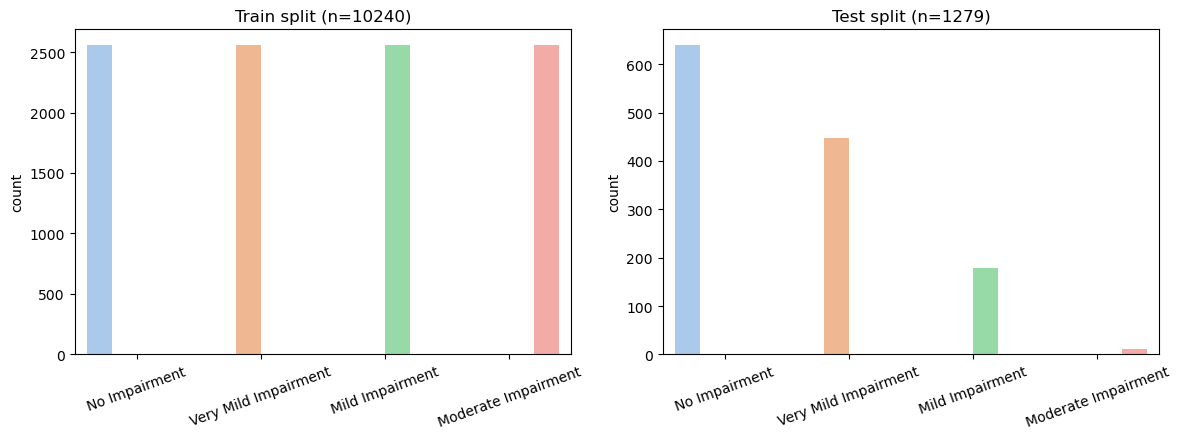

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, split in zip(axes, ["train", "test"]):
    sub = df[df["split"] == split]
    sns.countplot(data=sub, x="label", hue="label", order=CLASSES, legend=False, ax=ax)
    ax.set_title(f"{split.capitalize()} split (n={len(sub)})")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelrotation=20)
plt.tight_layout()
plt.show()

## 3. Sample images per class

A quick visual look at each class to see what distinguishes the categories to the eye before any modeling.

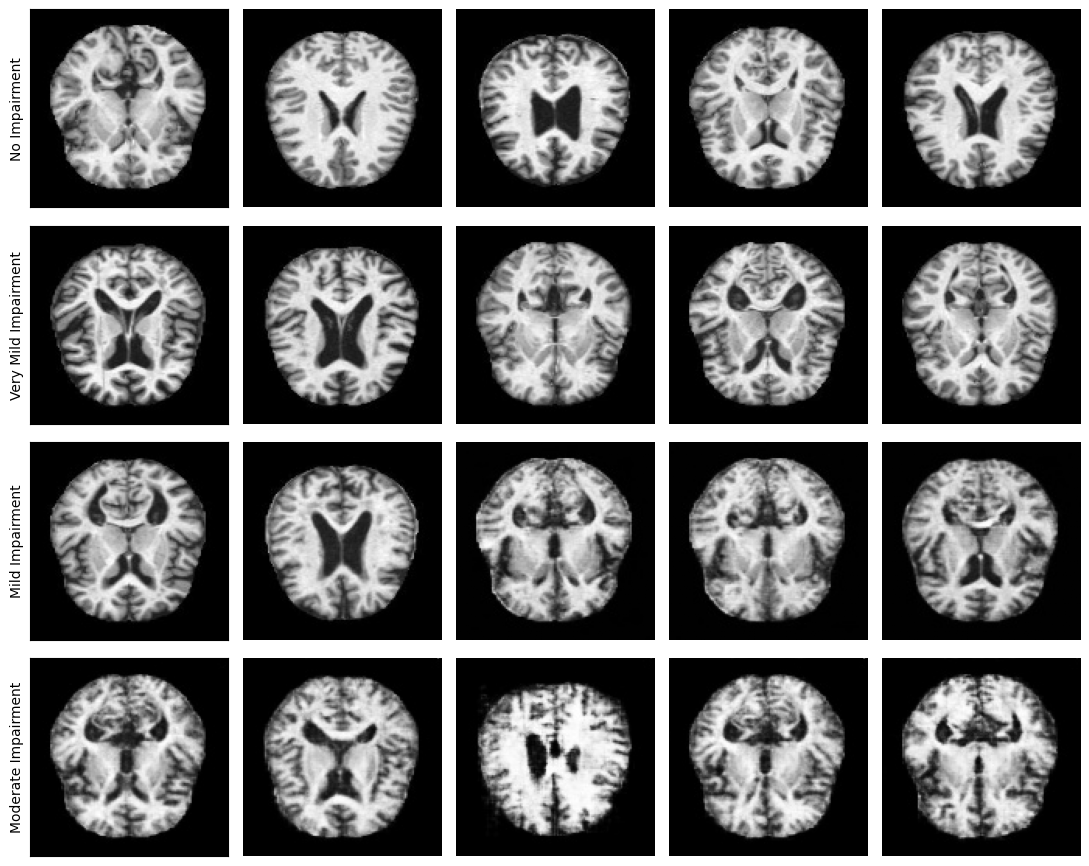

In [5]:
def load_gray(fp, size=None):
    img = Image.open(fp).convert("L")
    if size is not None:
        img = img.resize(size)
    return np.asarray(img)

rng = np.random.default_rng(RANDOM_STATE)
n_samples = 5

fig, axes = plt.subplots(len(CLASSES), n_samples, figsize=(2.2 * n_samples, 2.2 * len(CLASSES)))
for row, label in enumerate(CLASSES):
    paths = df.loc[(df["label"] == label) & (df["split"] == "train"), "filepath"].values
    chosen = rng.choice(paths, size=n_samples, replace=False)
    for col, fp in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(load_gray(fp), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(label)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(label, fontsize=10)
plt.tight_layout()
plt.show()

## 4. Image properties

Confirm all images share the same dimensions and pixel range so downstream processing (resizing, flattening) is straightforward.

In [6]:
sizes, modes = set(), set()
for fp in df["filepath"].sample(min(500, len(df)), random_state=RANDOM_STATE):
    with Image.open(fp) as im:
        sizes.add(im.size)
        modes.add(im.mode)
print("Unique sizes (sampled):", sizes)
print("Unique modes (sampled):", modes)

Unique sizes (sampled): {(128, 128)}
Unique modes (sampled): {'L'}


## 5. Average image per class

Averaging every training image within a class highlights the structural features that are consistent across a class — most notably differences in ventricle size and overall brain-tissue density, which are the classic radiological markers of Alzheimer's progression.

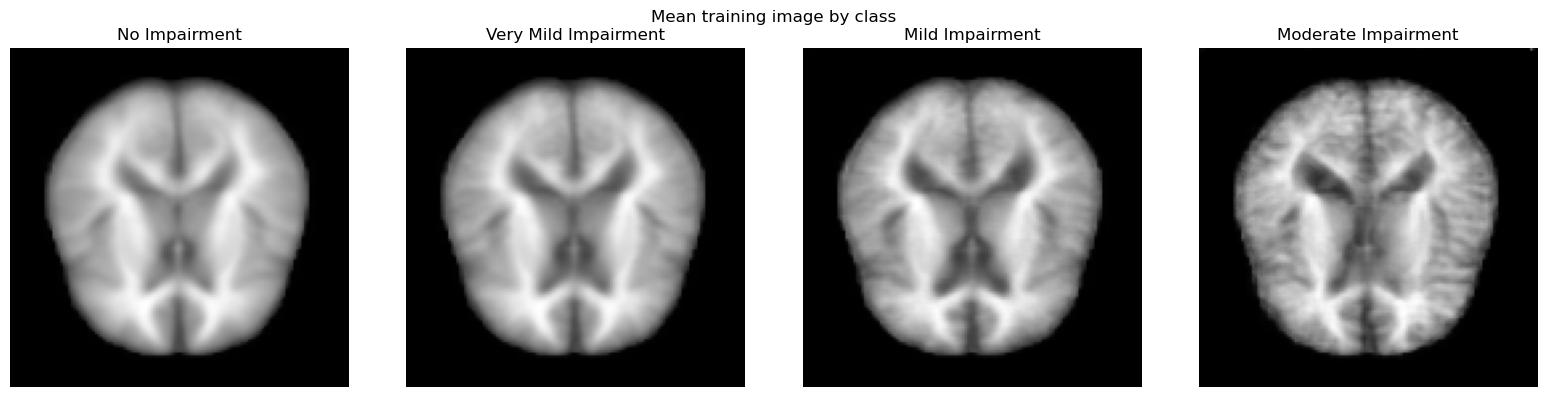

In [7]:
mean_images = {}
for label in CLASSES:
    paths = df.loc[(df["label"] == label) & (df["split"] == "train"), "filepath"].values
    stack = np.stack([load_gray(fp) for fp in paths]).astype(np.float32)
    mean_images[label] = stack.mean(axis=0)

fig, axes = plt.subplots(1, len(CLASSES), figsize=(4 * len(CLASSES), 4))
for ax, label in zip(axes, CLASSES):
    ax.imshow(mean_images[label], cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.suptitle("Mean training image by class")
plt.tight_layout()
plt.show()

## 6. Pixel-intensity distribution by class

Using mean pixel brightness per image as a simple scalar summary, compare the distributions across classes.

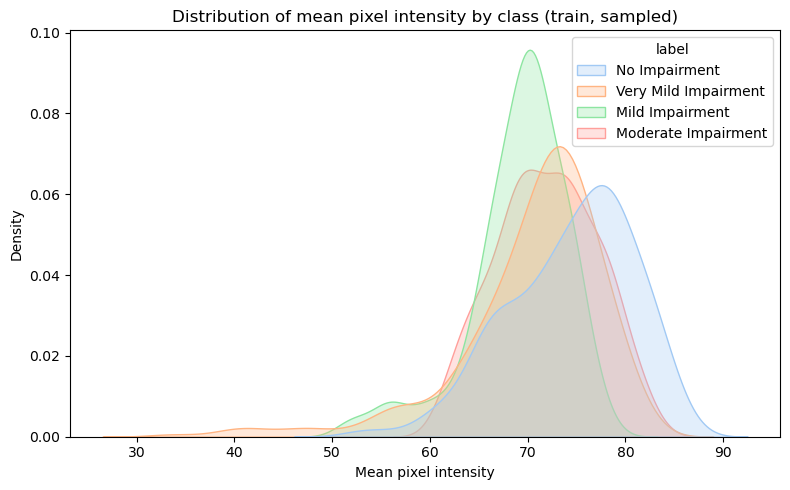

In [8]:
rng = np.random.default_rng(RANDOM_STATE)
sample_n = 300
rows = []
for label in CLASSES:
    paths = df.loc[(df["label"] == label) & (df["split"] == "train"), "filepath"].values
    chosen = rng.choice(paths, size=min(sample_n, len(paths)), replace=False)
    for fp in chosen:
        rows.append({"label": label, "mean_intensity": load_gray(fp).mean()})

intensity_df = pd.DataFrame(rows)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=intensity_df, x="mean_intensity", hue="label", hue_order=CLASSES, fill=True, alpha=0.3, common_norm=False)
plt.title("Distribution of mean pixel intensity by class (train, sampled)")
plt.xlabel("Mean pixel intensity")
plt.tight_layout()
plt.show()

## 7. Duplicate & near-duplicate images

This dataset is commonly built by heavily augmenting a small pool of source MRI scans, so before modeling it's worth checking how much of it is actually unique — and, critically, whether any of that duplication leaks across the train/test split (which would let a model "memorize" a test image it effectively already saw in training).

Two checks:
1. **Exact duplicates** — identical files, detected via MD5 hash of the raw bytes.
2. **Near-duplicates** — images that aren't byte-identical but are pixel-for-pixel almost the same (e.g. a re-saved or barely-cropped copy), detected via pairwise pixel correlation within each class at reduced resolution. A pair is flagged when correlation exceeds 0.995 — well above the similarity between two genuinely different brain scans, which typically share only coarse shape/structure.

In [9]:
def load_flat(fp, size=(64, 64)):
    return np.asarray(Image.open(fp).convert("L").resize(size), dtype=np.float32).flatten()

# --- exact duplicates (MD5 of raw file bytes) ---
hash_to_rows = {}
for row in df.itertuples():
    with open(row.filepath, "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    hash_to_rows.setdefault(h, []).append(row)

exact_dup_groups = [rows for rows in hash_to_rows.values() if len(rows) > 1]
exact_dup_files = sum(len(rows) - 1 for rows in exact_dup_groups)
exact_leak = [rows for rows in exact_dup_groups if len({r.split for r in rows}) > 1]

print(f"Exact-duplicate groups: {len(exact_dup_groups)} (covering {exact_dup_files} redundant files)")
print(f"Exact-duplicate groups spanning train+test: {len(exact_leak)}")

Exact-duplicate groups: 182 (covering 182 redundant files)
Exact-duplicate groups spanning train+test: 0


In [10]:
# --- near-duplicates (pixel correlation > 0.995), computed within each class ---
near_dup_summary = []
leak_examples = []

for label in CLASSES:
    sub = df[df["label"] == label]
    files = list(sub.itertuples())
    X = np.stack([load_flat(r.filepath) for r in files])
    Xn = X - X.mean(axis=1, keepdims=True)
    norms = np.linalg.norm(Xn, axis=1, keepdims=True)
    norms[norms == 0] = 1
    Xn /= norms
    sim = Xn @ Xn.T
    np.fill_diagonal(sim, -1)

    pairs = np.argwhere(sim > 0.995)
    pairs = pairs[pairs[:, 0] < pairs[:, 1]]
    cross_split = [(i, j) for i, j in pairs if files[i].split != files[j].split]

    near_dup_summary.append({
        "label": label, "n_images": len(files),
        "near_dup_pairs": len(pairs), "cross_split_leak_pairs": len(cross_split),
    })
    for i, j in cross_split[:3]:
        leak_examples.append((files[i].filepath, files[j].filepath, float(sim[i, j])))

near_dup_df = pd.DataFrame(near_dup_summary)
near_dup_df

,label,n_images,near_dup_pairs,cross_split_leak_pairs
0,No Impairment,3200,7,3
1,Very Mild Impairment,3008,60,0
2,Mild Impairment,2739,138,0
3,Moderate Impairment,2572,7003,0


One class has far more near-duplicate pairs than the others. Rather than just counting pairs, cluster them (union-find over the >0.995 similarity graph) to see how many *truly distinct* source scans that class' images actually trace back to.

In [11]:
standout_label = near_dup_df.sort_values("near_dup_pairs", ascending=False).iloc[0]["label"]
sub = df[df["label"] == standout_label]
files = list(sub.itertuples())
X = np.stack([load_flat(r.filepath) for r in files])
Xn = X - X.mean(axis=1, keepdims=True)
norms = np.linalg.norm(Xn, axis=1, keepdims=True)
norms[norms == 0] = 1
Xn /= norms
sim = Xn @ Xn.T
np.fill_diagonal(sim, -1)

n = len(files)
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for i, j in np.argwhere(sim > 0.995):
    if i < j:
        union(int(i), int(j))

cluster_sizes = pd.Series([find(i) for i in range(n)]).value_counts()
print(f"{standout_label}: {n} images collapse to {len(cluster_sizes)} near-duplicate clusters")
print("Largest cluster sizes:", cluster_sizes.head(10).tolist())
print(f"Images in the two largest clusters alone: {cluster_sizes.head(2).sum()} / {n} "
      f"({cluster_sizes.head(2).sum() / n:.0%})")

Moderate Impairment: 2572 images collapse to 944 near-duplicate clusters
Largest cluster sizes: [749, 654, 14, 13, 12, 11, 10, 9, 8, 8]
Images in the two largest clusters alone: 1403 / 2572 (55%)


`Moderate Impairment` stands out: thousands of near-duplicate pairs among only ~2,570 images, and clustering them together shows the class collapses to a handful of dominant source scans — the two largest clusters alone account for over half the images. The "balanced" 2,560-image training count for this class therefore represents far fewer truly unique brains than the other three classes.

More importantly for model evaluation: a small number of near-duplicate pairs do cross the train/test boundary in `No Impairment` (confirmed below with pixel-difference error, not just correlation — these are near-identical, not just similarly shaped). That's mild train/test leakage, and it means the earlier baseline's test accuracy is very slightly optimistic for that class, though the effect is small (a handful of pairs out of hundreds of test images).

NoImpairment (1058).jpg vs 15 (5).jpg: cosine sim=0.9953, pixel MSE=116.5 (128x128, 0-255 scale)
NoImpairment (1363).jpg vs 16 (89).jpg: cosine sim=0.9950, pixel MSE=119.1 (128x128, 0-255 scale)
NoImpairment (815).jpg vs 10 (6).jpg: cosine sim=0.9953, pixel MSE=116.0 (128x128, 0-255 scale)


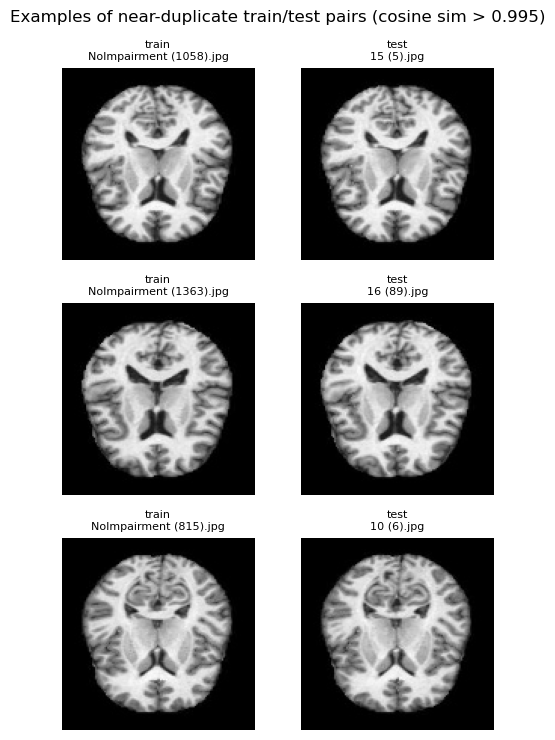

In [12]:
def load_full(fp, size=(128, 128)):
    return np.asarray(Image.open(fp).convert("L").resize(size), dtype=np.float32)

if leak_examples:
    fig, axes = plt.subplots(len(leak_examples), 2, figsize=(5, 2.5 * len(leak_examples)))
    for row, (fp_a, fp_b, sim_val) in enumerate(leak_examples):
        mse = float(np.mean((load_full(fp_a) - load_full(fp_b)) ** 2))
        for col, fp in enumerate([fp_a, fp_b]):
            ax = axes[row, col] if len(leak_examples) > 1 else axes[col]
            ax.imshow(Image.open(fp).convert("L"), cmap="gray")
            ax.set_title(f"{fp.split('/')[-3]}\n{os.path.basename(fp)}", fontsize=8)
            ax.axis("off")
        print(f"{os.path.basename(fp_a)} vs {os.path.basename(fp_b)}: "
              f"cosine sim={sim_val:.4f}, pixel MSE={mse:.1f} (128x128, 0-255 scale)")
    plt.suptitle("Examples of near-duplicate train/test pairs (cosine sim > 0.995)")
    plt.tight_layout()
    plt.show()
else:
    print("No cross-split near-duplicates found.")

## 8. Classical ML baseline

Deep learning frameworks (TensorFlow/PyTorch) aren't part of this environment, so as a baseline we test how separable the classes are using classical models on downsampled, flattened pixel data reduced with PCA — the same "compare several classifiers on one feature set" approach used in the [lipidomics notebook](lipidomics_notebook.ipynb).

Images are downsampled to 32x32 (1024 features) before flattening, both to keep the classical models tractable and because fine pixel-level detail isn't useful to a linear/PCA-based model anyway.

Training uses the balanced `train` split; evaluation uses the realistic, imbalanced `test` split.

In [13]:
IMG_SIZE = (32, 32)

def load_dataset(sub_df):
    X = np.stack([load_gray(fp, size=IMG_SIZE).flatten() for fp in sub_df["filepath"]])
    y = sub_df["label"].astype(str).values
    return X.astype(np.float32), y

train_df = df[df["split"] == "train"]
test_df = df[df["split"] == "test"]

X_train, y_train = load_dataset(train_df)
X_test, y_test = load_dataset(test_df)
X_train.shape, X_test.shape

((10240, 1024), (1279, 1024))

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.3f}")

Explained variance retained: 0.825


In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF)": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}

results = []
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    preds = model.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    macro_recall = report["macro avg"]["recall"]
    results.append({"Model": name, "Accuracy": acc, "Macro Recall": macro_recall})

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Macro Recall
0,KNN,0.932760,0.948143
1,Random Forest,0.916341,0.859166
2,SVM (RBF),0.693511,0.677761
3,Logistic Regression,0.595778,0.637149
4,Naive Bayes,0.513683,0.358355


**Macro recall** (unweighted average recall across the four classes) matters more than accuracy here, since the test set is dominated by `No Impairment` and `Very Mild Impairment` — a model could score high accuracy just by ignoring the rare `Moderate Impairment` class.

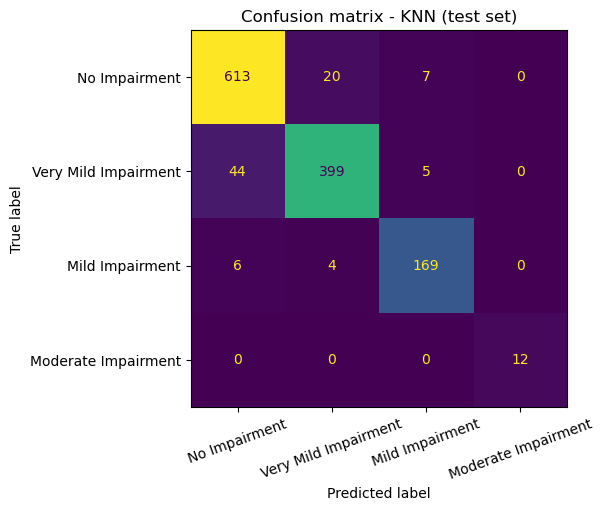

                      precision    recall  f1-score   support

     Mild Impairment       0.93      0.94      0.94       179
 Moderate Impairment       1.00      1.00      1.00        12
       No Impairment       0.92      0.96      0.94       640
Very Mild Impairment       0.94      0.89      0.92       448

            accuracy                           0.93      1279
           macro avg       0.95      0.95      0.95      1279
        weighted avg       0.93      0.93      0.93      1279



In [16]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]
preds = best_model.predict(X_test_pca)

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, preds, labels=CLASSES, xticks_rotation=20, ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix - {best_name} (test set)")
plt.tight_layout()
plt.show()

print(classification_report(y_test, preds, zero_division=0))

## Conclusion

- The MRI images are well-organized into four ordered impairment classes, with a balanced `train` split and a realistically imbalanced `test` split (Moderate Impairment is rare — only 12 test images).
- The per-class mean images show a visible structural gradient across classes, consistent with the expected radiological pattern of ventricle enlargement and tissue loss as impairment increases.
- The dataset contains real duplication: exact byte-identical duplicates within `train` (no cross-split leakage), heavy near-duplicate clustering in `Moderate Impairment` (its 2,560 "balanced" training images trace back to a much smaller set of unique scans), and a small amount of genuine near-duplicate leakage between `train` and `test` in `No Impairment`. This means the reported class balance somewhat overstates true image diversity, and baseline test accuracy is very slightly optimistic.
- Even without deep learning, a classical PCA + classifier pipeline on downsampled pixels separates the classes well above chance, indicating the raw imaging data carries real signal about disease severity — though it likely underperforms a CNN, which can exploit spatial structure that flattening discards.
- The rare `Moderate Impairment` class is the hardest to detect reliably given how few test examples exist for it; macro recall (rather than raw accuracy) is the more honest metric to track, and would be worth revisiting with a CNN or data augmentation for that class specifically — ideally after deduplicating its dominant near-duplicate clusters.
